In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

data = fetch_ucirepo(id=468)
X = data.data.features
y = data.data.targets

df = pd.concat([X, y], axis=1)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [2]:
df.to_csv('../data/raw/online_shoppers_intention.csv', index=False)

In [3]:
print(df.shape)
df.info()

(12330, 18)
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType          

In [4]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [5]:
df['Revenue'].value_counts()
df['Revenue'].value_counts(normalize=True) * 100

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

In [6]:
df.duplicated().sum()

np.int64(125)

In [7]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [8]:
df['Revenue'].value_counts()
df['Revenue'].value_counts(normalize=True) * 100

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

In [9]:
print(df['Revenue'].value_counts())
print(df['Revenue'].value_counts(normalize=True) * 100)

Revenue
False    10422
True      1908
Name: count, dtype: int64
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


In [10]:
df = df.drop_duplicates()
print(df.shape)
print(df.duplicated().sum())

(12205, 18)
0


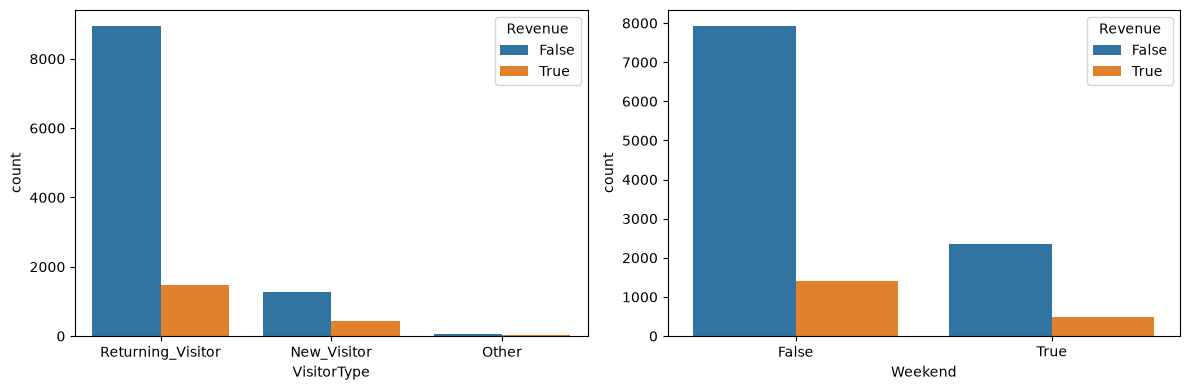

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='VisitorType', hue='Revenue', ax=axes[0])
sns.countplot(data=df, x='Weekend', hue='Revenue', ax=axes[1])
plt.tight_layout()
plt.show()

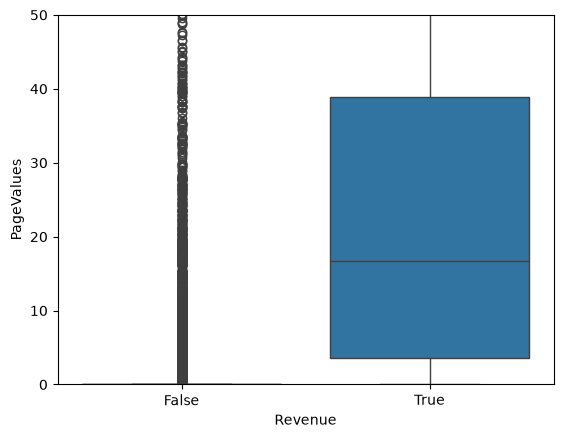

In [12]:
sns.boxplot(data=df, x='Revenue', y='PageValues')
plt.ylim(0, 50)  # zoom in, since it's heavily right-skewed
plt.show()

In [13]:
df_encoded = df.copy()
df_encoded['Weekend'] = df_encoded['Weekend'].astype(int)
df_encoded['Revenue'] = df_encoded['Revenue'].astype(int)

df_encoded = pd.get_dummies(df_encoded, columns=['Month', 'VisitorType'], drop_first=True)

df_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


In [14]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(9764, 26) (2441, 26)
0.15628840639082342 0.15649324047521507


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score)

lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
lr.fit(X_train, y_train)

pred = lr.predict(X_test)
proba = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred, digits=3))
print(confusion_matrix(y_test, pred))
print('ROC-AUC:', roc_auc_score(y_test, proba))
print('PR-AUC:', average_precision_score(y_test, proba))

              precision    recall  f1-score   support

           0      0.956     0.864     0.907      2059
           1      0.516     0.785     0.623       382

    accuracy                          0.851      2441
   macro avg      0.736     0.824     0.765      2441
weighted avg      0.887     0.851     0.863      2441

[[1778  281]
 [  82  300]]
ROC-AUC: 0.9110341776239673
PR-AUC: 0.6644114677320931


In [16]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate(name, model):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        'model': name,
        'abandon_recall': recall_score(y_test, pred, pos_label=0),
        'abandon_precision': precision_score(y_test, pred, pos_label=0),
        'purchase_recall': recall_score(y_test, pred),
        'purchase_precision': precision_score(y_test, pred),
        'purchase_f1': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
        'pr_auc': average_precision_score(y_test, proba),
    }

spw = (y_train == 0).sum() / (y_train == 1).sum()

results = [
    evaluate('LogReg', lr),
    evaluate('RandomForest', RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)),
    evaluate('XGBoost', XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        scale_pos_weight=spw, eval_metric='logloss', random_state=42)),
]

pd.DataFrame(results).round(3)

,model,abandon_recall,abandon_precision,purchase_recall,purchase_precision,purchase_f1,roc_auc,pr_auc
0,LogReg,0.864,0.956,0.785,0.516,0.623,0.911,0.664
1,RandomForest,0.921,0.949,0.736,0.634,0.681,0.929,0.734
2,XGBoost,0.872,0.967,0.838,0.549,0.663,0.934,0.746


In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    'LogReg': Pipeline([('scaler', StandardScaler()),
                        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))]),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                             scale_pos_weight=spw, eval_metric='logloss', random_state=42),
}

for name, model in candidates.items():
    s = cross_validate(model, X_train, y_train, cv=cv,
                       scoring=['roc_auc', 'average_precision'])
    print(f"{name:13s} ROC-AUC {s['test_roc_auc'].mean():.3f} ± {s['test_roc_auc'].std():.3f} | "
          f"PR-AUC {s['test_average_precision'].mean():.3f} ± {s['test_average_precision'].std():.3f}")

LogReg        ROC-AUC 0.900 ± 0.012 | PR-AUC 0.647 ± 0.024
RandomForest  ROC-AUC 0.930 ± 0.004 | PR-AUC 0.740 ± 0.019
XGBoost       ROC-AUC 0.929 ± 0.007 | PR-AUC 0.748 ± 0.025


XGB weighted | Brier: 0.099 | PR-AUC: 0.746
XGB unweighted | Brier: 0.0688 | PR-AUC: 0.749


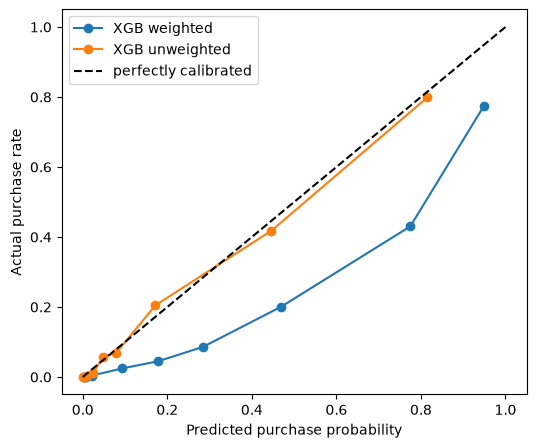

In [19]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

base = dict(n_estimators=300, learning_rate=0.05, max_depth=4,
            eval_metric='logloss', random_state=42)

models = {
    'XGB weighted': XGBClassifier(**base, scale_pos_weight=spw),
    'XGB unweighted': XGBClassifier(**base),
}

plt.figure(figsize=(6, 5))
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict_proba(X_test)[:, 1]
    print(name, '| Brier:', round(brier_score_loss(y_test, p), 4),
          '| PR-AUC:', round(average_precision_score(y_test, p), 3))
    frac, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac, marker='o', label=name)

plt.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
plt.xlabel('Predicted purchase probability')
plt.ylabel('Actual purchase rate')
plt.legend()
plt.show()

In [20]:
final = models['XGB unweighted']
p_purchase = final.predict_proba(X_test)[:, 1]
p_abandon = 1 - p_purchase

def risk_level(p, low=0.40, high=0.70):
    if p >= high:
        return 'High'
    if p >= low:
        return 'Medium'
    return 'Low'

out = pd.DataFrame({'p_abandon': p_abandon, 'abandoned': 1 - y_test.values})
out['risk'] = out['p_abandon'].apply(risk_level)

summary = out.groupby('risk').agg(
    sessions=('abandoned', 'size'),
    actual_abandon_rate=('abandoned', 'mean')
).reindex(['Low', 'Medium', 'High'])
summary['share_of_sessions'] = summary['sessions'] / len(out)
print(summary.round(3))

        sessions  actual_abandon_rate  share_of_sessions
risk                                                    
Low          257                0.222              0.105
Medium       210                0.557              0.086
High        1974                0.955              0.809


In [21]:
def band_table(low, high):
    r = out['p_abandon'].apply(lambda p: risk_level(p, low, high))
    t = out.assign(risk=r).groupby('risk').agg(
        sessions=('abandoned', 'size'),
        actual_abandon_rate=('abandoned', 'mean')
    ).reindex(['Low', 'Medium', 'High'])
    t['share'] = t['sessions'] / len(out)
    return t.round(3)

for low, high in [(0.40, 0.70), (0.60, 0.90), (0.70, 0.95), (0.80, 0.98)]:
    print(f'--- low={low}, high={high}')
    print(band_table(low, high), '\n')

--- low=0.4, high=0.7
        sessions  actual_abandon_rate  share
risk                                        
Low          257                0.222  0.105
Medium       210                0.557  0.086
High        1974                0.955  0.809 

--- low=0.6, high=0.9
        sessions  actual_abandon_rate  share
risk                                        
Low          398                0.322  0.163
Medium       342                0.772  0.140
High        1701                0.980  0.697 

--- low=0.7, high=0.95
        sessions  actual_abandon_rate  share
risk                                        
Low          467                0.373  0.191
Medium       599                0.870  0.245
High        1375                0.992  0.563 

--- low=0.8, high=0.98
        sessions  actual_abandon_rate  share
risk                                        
Low          568                0.440  0.233
Medium       833                0.926  0.341
High        1040                0.998  0.426 



In [22]:
from sklearn.model_selection import cross_val_predict

oof = cross_val_predict(
    XGBClassifier(**base), X_train, y_train, cv=cv, method='predict_proba'
)[:, 1]

chk = pd.DataFrame({'p_abandon': 1 - oof, 'abandoned': 1 - y_train.values})
chk['risk'] = chk['p_abandon'].apply(lambda p: risk_level(p, 0.80, 0.98))

t = chk.groupby('risk').agg(
    sessions=('abandoned', 'size'),
    actual_abandon_rate=('abandoned', 'mean')
).reindex(['Low', 'Medium', 'High'])
t['share'] = t['sessions'] / len(chk)
print(t.round(3))

        sessions  actual_abandon_rate  share
risk                                        
Low         2195                0.436  0.225
Medium      3317                0.917  0.340
High        4252                0.997  0.435


In [23]:
LOW, HIGH = 0.80, 0.98
hv_cut = X_train['ProductRelated'].quantile(0.75)

rules = X_test.copy()
rules['p_abandon'] = p_abandon
rules['risk'] = rules['p_abandon'].apply(lambda p: risk_level(p, LOW, HIGH))
rules['is_new'] = (rules['VisitorType_Returning_Visitor'] == 0) & (rules['VisitorType_Other'] == 0)
rules['high_value'] = rules['ProductRelated'] >= hv_cut
rules['checkout_proxy'] = rules['PageValues'] > 0

def action(r):
    if r['risk'] == 'Low':
        return 'No immediate action'
    if r['risk'] == 'Medium':
        return 'Cart reminder'
    if r['is_new']:
        return 'First-purchase incentive'
    if r['high_value']:
        return 'Discount / free shipping offer'
    if r['checkout_proxy']:
        return 'Checkout reminder'
    return 'Cart reminder'

rules['action'] = rules.apply(action, axis=1)
print(pd.crosstab(rules['risk'], rules['action']))

action  Cart reminder  Discount / free shipping offer  \
risk                                                    
High              857                             101   
Low                 0                               0   
Medium            833                               0   

action  First-purchase incentive  No immediate action  
risk                                                   
High                          82                    0  
Low                            0                  568  
Medium                         0                    0  


In [24]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


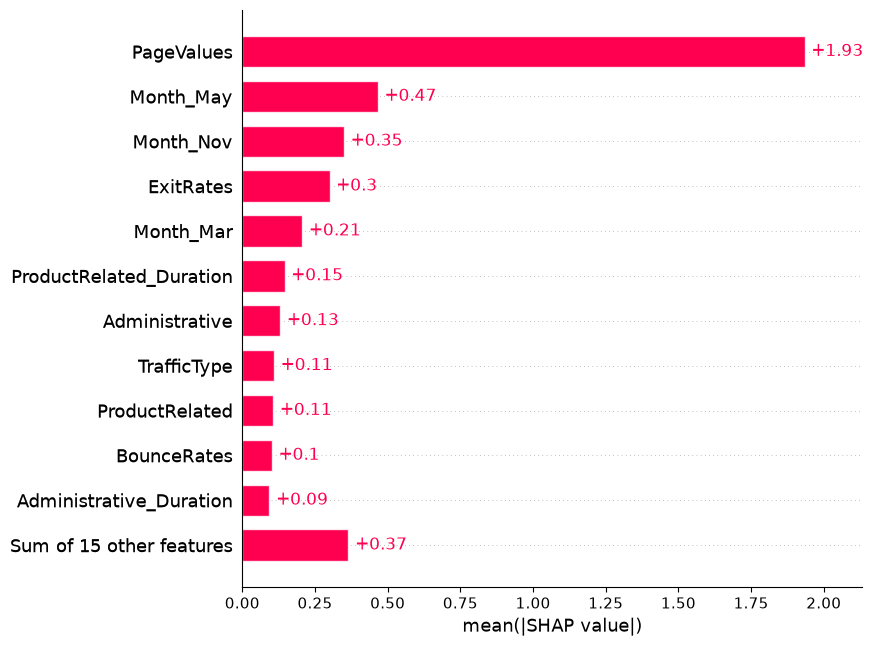

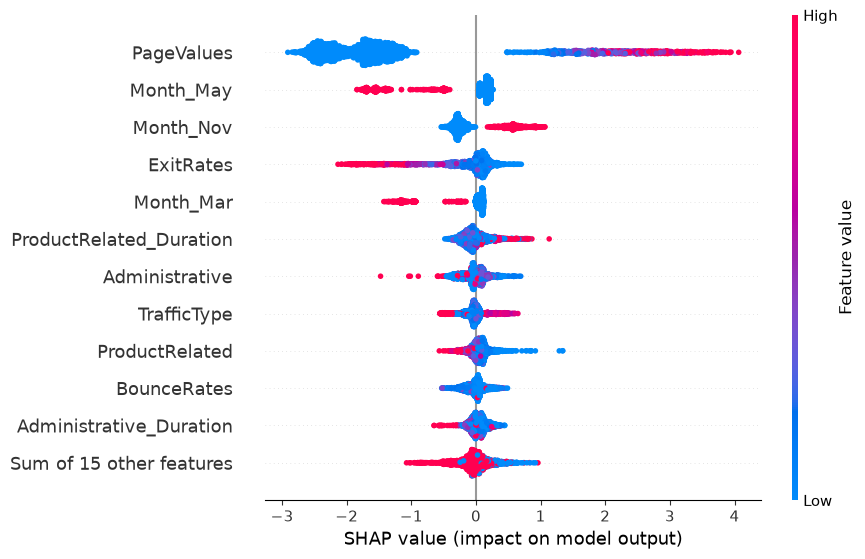

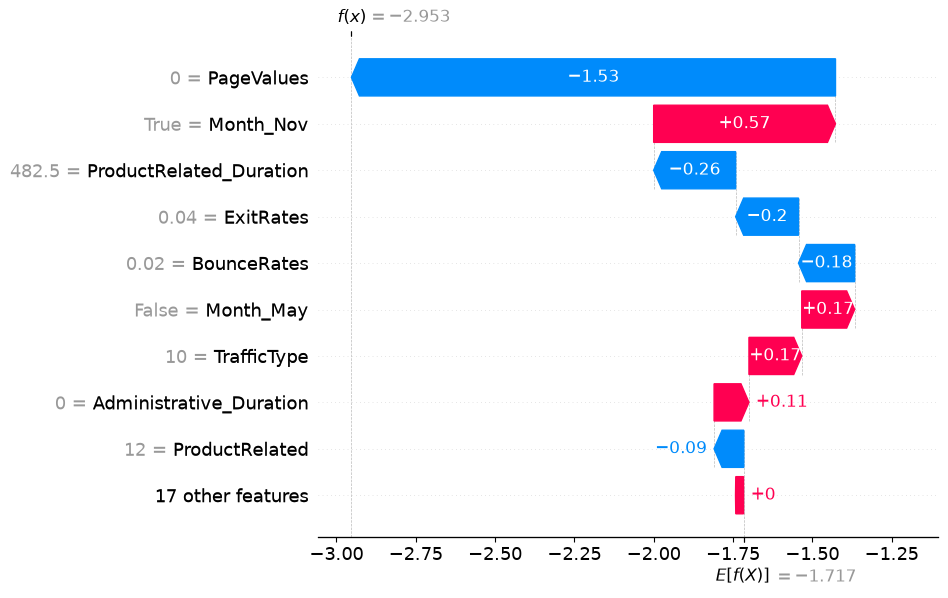

In [25]:
import shap

explainer = shap.TreeExplainer(final)
shap_values = explainer(X_test)

# global view: which features matter most overall
shap.plots.bar(shap_values, max_display=12)

# direction of effect for each feature
shap.plots.beeswarm(shap_values, max_display=12)

# one session, explained
shap.plots.waterfall(shap_values[0])

In [26]:
X_train_np = X_train.drop(columns='PageValues')

for name, feats in [('with PageValues', X_train), ('without PageValues', X_train_np)]:
    s = cross_validate(XGBClassifier(**base), feats, y_train, cv=cv,
                       scoring=['roc_auc', 'average_precision'])
    print(f"{name:20s} ROC-AUC {s['test_roc_auc'].mean():.3f} | "
          f"PR-AUC {s['test_average_precision'].mean():.3f}")

with PageValues      ROC-AUC 0.930 | PR-AUC 0.749
without PageValues   ROC-AUC 0.778 | PR-AUC 0.377


In [27]:
READABLE = {
    'PageValues': 'Page value',
    'ExitRates': 'Exit rate',
    'BounceRates': 'Bounce rate',
    'ProductRelated': 'Product pages viewed',
    'ProductRelated_Duration': 'Time on product pages',
    'Administrative': 'Account/admin pages viewed',
    'Administrative_Duration': 'Time on account/admin pages',
    'Informational': 'Info pages viewed',
    'Informational_Duration': 'Time on info pages',
    'TrafficType': 'Traffic source',
}

def top_factors(row_df, k=5):
    sv = explainer(row_df)
    contrib = pd.Series(-sv.values[0], index=row_df.columns)  # positive = pushes toward abandonment
    factors = []
    for feat in contrib.abs().sort_values(ascending=False).index:
        val = row_df.iloc[0][feat]
        if feat.startswith(('Month_', 'VisitorType_')) and not val:
            continue  # skip inactive dummies
        if feat.startswith('Month_'):
            label = f"Month: {feat[6:]}"
        elif feat.startswith('VisitorType_'):
            label = f"Visitor type: {feat[12:]}"
        else:
            label = READABLE.get(feat, feat)
        factors.append({
            'factor': label,
            'value': float(val) if not isinstance(val, (bool, np.bool_)) else bool(val),
            'effect': 'raises abandonment risk' if contrib[feat] > 0 else 'lowers abandonment risk',
            'impact': round(float(abs(contrib[feat])), 3),
        })
        if len(factors) == k:
            break
    return factors

import numpy as np
for i in [0, 1, 2]:
    print(f"--- test session {i} | p_abandon = {p_abandon[i]:.3f}")
    for f in top_factors(X_test.iloc[[i]]):
        print(f)

--- test session 0 | p_abandon = 0.950
{'factor': 'Page value', 'value': 0.0, 'effect': 'raises abandonment risk', 'impact': 1.526}
{'factor': 'Month: Nov', 'value': True, 'effect': 'lowers abandonment risk', 'impact': 0.573}
{'factor': 'Time on product pages', 'value': 482.5, 'effect': 'raises abandonment risk', 'impact': 0.258}
{'factor': 'Exit rate', 'value': 0.04, 'effect': 'raises abandonment risk', 'impact': 0.198}
{'factor': 'Bounce rate', 'value': 0.02, 'effect': 'raises abandonment risk', 'impact': 0.177}
--- test session 1 | p_abandon = 0.972
{'factor': 'Page value', 'value': 0.0, 'effect': 'raises abandonment risk', 'impact': 1.871}
{'factor': 'Time on product pages', 'value': 473.2833333, 'effect': 'raises abandonment risk', 'impact': 0.105}
{'factor': 'Exit rate', 'value': 0.002222222, 'effect': 'raises abandonment risk', 'impact': 0.087}
{'factor': 'Bounce rate', 'value': 0.0, 'effect': 'lowers abandonment risk', 'impact': 0.076}
{'factor': 'Month: Oct', 'value': True, 'e

In [28]:
import joblib, json

bundle = {
    'model': final,
    'columns': list(X_train.columns),
    'low': LOW, 'high': HIGH,
    'hv_cut': float(hv_cut),
}
joblib.dump(bundle, '../models/cart_abandonment_xgb.joblib')

def predict_session(raw, customer_id=None, session_id=None, min_impact=0.05):
    cols = bundle['columns']
    row = pd.DataFrame(0.0, index=[0], columns=cols)
    for k, v in raw.items():
        if k in ('Month', 'VisitorType'):
            c = f'{k}_{v}'
            if c in row.columns:      # Aug and New_Visitor are the dropped baselines
                row.loc[0, c] = 1.0
        elif k in row.columns:
            row.loc[0, k] = float(v)

    p_ab = float(1 - bundle['model'].predict_proba(row)[0, 1])
    risk = risk_level(p_ab, bundle['low'], bundle['high'])

    is_new = row.loc[0, 'VisitorType_Returning_Visitor'] == 0 and row.loc[0, 'VisitorType_Other'] == 0
    r = {'risk': risk, 'is_new': is_new,
         'high_value': row.loc[0, 'ProductRelated'] >= bundle['hv_cut'],
         'checkout_proxy': row.loc[0, 'PageValues'] > 0}

    factors = [f for f in top_factors(row, k=5) if f['impact'] >= min_impact]
    return {
        'customer_id': customer_id,
        'session_id': session_id,
        'abandonment_probability': round(p_ab, 3),
        'risk_level': risk,
        'recommended_action': action(r),
        'important_factors': factors,
    }

example = {
    'Administrative': 0, 'Administrative_Duration': 0,
    'Informational': 0, 'Informational_Duration': 0,
    'ProductRelated': 8, 'ProductRelated_Duration': 300,
    'BounceRates': 0.02, 'ExitRates': 0.05, 'PageValues': 0,
    'SpecialDay': 0, 'OperatingSystems': 2, 'Browser': 2,
    'Region': 1, 'TrafficType': 2, 'Weekend': False,
    'Month': 'Nov', 'VisitorType': 'New_Visitor',
}
print(json.dumps(predict_session(example, 'C001', 'S1001'), indent=2))

example['PageValues'] = 30
print(json.dumps(predict_session(example, 'C001', 'S1002'), indent=2))

{
  "customer_id": "C001",
  "session_id": "S1001",
  "abandonment_probability": 0.929,
  "risk_level": "Medium",
  "recommended_action": "Cart reminder",
  "important_factors": [
    {
      "factor": "Page value",
      "value": 0.0,
      "effect": "raises abandonment risk",
      "impact": 1.597
    },
    {
      "factor": "Month: Nov",
      "value": 1.0,
      "effect": "lowers abandonment risk",
      "impact": 0.599
    },
    {
      "factor": "Exit rate",
      "value": 0.05,
      "effect": "raises abandonment risk",
      "impact": 0.328
    },
    {
      "factor": "Time on account/admin pages",
      "value": 0.0,
      "effect": "lowers abandonment risk",
      "impact": 0.169
    },
    {
      "factor": "Time on product pages",
      "value": 300.0,
      "effect": "raises abandonment risk",
      "impact": 0.155
    }
  ]
}
{
  "customer_id": "C001",
  "session_id": "S1002",
  "abandonment_probability": 0.224,
  "risk_level": "Low",
  "recommended_action": "No immedi

In [29]:
import sys, json
sys.path.append('..')
from src.predict import predict_session

weak = {
    'Administrative': 0, 'Administrative_Duration': 0,
    'Informational': 0, 'Informational_Duration': 0,
    'ProductRelated': 1, 'ProductRelated_Duration': 0,
    'BounceRates': 0.2, 'ExitRates': 0.2, 'PageValues': 0,
    'SpecialDay': 0, 'OperatingSystems': 1, 'Browser': 1,
    'Region': 1, 'TrafficType': 1, 'Weekend': False,
    'Month': 'May', 'VisitorType': 'New_Visitor',
}
print(json.dumps(predict_session(weak, 'C002', 'S2001'), indent=2))

{
  "customer_id": "C002",
  "session_id": "S2001",
  "abandonment_probability": 1.0,
  "risk_level": "High",
  "recommended_action": "First-purchase incentive",
  "important_factors": [
    {
      "factor": "Page value",
      "value": 0.0,
      "effect": "raises abandonment risk",
      "impact": 2.383
    },
    {
      "factor": "Exit rate",
      "value": 0.2,
      "effect": "raises abandonment risk",
      "impact": 1.611
    },
    {
      "factor": "Month: May",
      "value": 1.0,
      "effect": "raises abandonment risk",
      "impact": 1.352
    },
    {
      "factor": "Account/admin pages viewed",
      "value": 0.0,
      "effect": "raises abandonment risk",
      "impact": 0.337
    },
    {
      "factor": "Product pages viewed",
      "value": 1.0,
      "effect": "lowers abandonment risk",
      "impact": 0.325
    }
  ]
}
